In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import GroupShuffleSplit

SELECTED_CHANNELS = [
    "flex_1", "flex_2", "flex_3", "flex_4", "flex_5",
    "ACCx",   "ACCy",   "ACCz",
    "GYRx",   "GYRy",   "GYRz",
]
FLEX_COLS    = ["flex_1", "flex_2", "flex_3", "flex_4", "flex_5"]
IMU_COLS     = ["ACCx", "ACCy", "ACCz", "GYRx", "GYRy", "GYRz"]
LABEL_COL    = "label"
SUBJECT_COL  = "subject"
WINDOW_SIZE  = 50
STRIDE_TRAIN = 50
STRIDE_EVAL  = 25
N_CLASSES    = 40
DATA_DIR     = "/home/juan/Documentos/notebooks/ASL-Sensor-Dataglove-Dataset"

np.random.seed(42)


def load_dataset(data_dir):
    frames = []
    for root, _, files in os.walk(data_dir):
        for fname in sorted(files):
            if fname.endswith(".csv"):
                file_path = os.path.join(root, fname)
                df = pd.read_csv(file_path)
                if LABEL_COL not in df.columns:
                    df[LABEL_COL] = fname.replace(".csv", "")
                if SUBJECT_COL not in df.columns:
                    df[SUBJECT_COL] = os.path.basename(root)
                df["source_file"] = fname
                frames.append(df)
    dataset = pd.concat(frames, ignore_index=True).dropna()
    return dataset


def split_by_subject(df, test_size=0.15, val_size=0.15, random_state=42):
    groups = df[SUBJECT_COL].values
    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    trainval_idx, test_idx = next(gss1.split(df, groups=groups))

    df_trainval = df.iloc[trainval_idx].reset_index(drop=True)
    df_test     = df.iloc[test_idx   ].reset_index(drop=True)

    rel_val = val_size / (1.0 - test_size)
    groups_trainval = df_trainval[SUBJECT_COL].values
    gss2 = GroupShuffleSplit(n_splits=1, test_size=rel_val, random_state=random_state)
    train_idx, val_idx = next(gss2.split(df_trainval, groups=groups_trainval))

    df_train = df_trainval.iloc[train_idx].reset_index(drop=True)
    df_val   = df_trainval.iloc[val_idx  ].reset_index(drop=True)
    return df_train, df_val, df_test


def extract_windows(df, channels, window_size=WINDOW_SIZE, stride=STRIDE_TRAIN, label_map=None):
    X_windows, y_windows = [], []
    for _, subj_df in df.groupby(SUBJECT_COL):
        values = subj_df[channels].values
        labels = subj_df[LABEL_COL].values
        for start in range(0, len(values) - window_size + 1, stride):
            end = start + window_size
            window_labels = labels[start:end]
            if len(np.unique(window_labels)) == 1:
                X_windows.append(values[start:end])
                y_windows.append(window_labels[0])

    X     = np.array(X_windows, dtype=np.float32)
    y_raw = np.array(y_windows)

    if label_map is None:
        unique_labels = sorted(np.unique(y_raw))
        label_map = {lbl: idx for idx, lbl in enumerate(unique_labels)}

    y = np.array([label_map[lbl] for lbl in y_raw], dtype=np.int32)
    return X, y, label_map

def fit_hybrid_scaler_global(df_train):
    scaler_flex = MinMaxScaler()
    scaler_imu  = StandardScaler()

    scaler_flex.fit(df_train[FLEX_COLS])
    scaler_imu.fit(df_train[IMU_COLS])

    params = {
        "flex_min":   scaler_flex.data_min_.tolist(),
        "flex_max":   scaler_flex.data_max_.tolist(),
        "flex_range": scaler_flex.data_range_.tolist(),
        "imu_mean":   scaler_imu.mean_.tolist(),
        "imu_std":    scaler_imu.scale_.tolist(),
    }
    return scaler_flex, scaler_imu, params


def apply_hybrid_scaler(df, scaler_flex, scaler_imu):
    df = df.copy()
    df[FLEX_COLS] = scaler_flex.transform(df[FLEX_COLS])
    df[IMU_COLS]  = scaler_imu.transform(df[IMU_COLS])
    return df

def export_scaler_to_c_header(params, output_path="scaler_params.h"):
    def fmt_array(values):
        return ", ".join(f"{v:.8f}f" for v in values)

    content = f"""\
#pragma once
#ifdef __cplusplus
extern "C" {{
#endif

// Ordem de features no vetor de entrada do modelo (11 canais):
// [flex_1, flex_2, flex_3, flex_4, flex_5, ACCx, ACCy, ACCz, GYRx, GYRy, GYRz]
#define ASL_N_FEATURES  11
#define ASL_WINDOW_SIZE 50
#define ASL_N_CLASSES   {N_CLASSES}

// ── MinMaxScaler para sensores de FLEXÃO (índices 0..4) ──────────────────────
// Fórmula: norm = clamp((raw - FLEX_MIN[i]) / FLEX_RANGE[i], 0.0f, 1.0f)
static const float ASL_FLEX_MIN[5]   = {{ {fmt_array(params["flex_min"])} }};
static const float ASL_FLEX_RANGE[5] = {{ {fmt_array(params["flex_range"])} }};

// ── StandardScaler para IMU (índices 5..10: ACCx,ACCy,ACCz,GYRx,GYRy,GYRz) ─
// Fórmula: norm = (raw - IMU_MEAN[i]) / IMU_STD[i]
static const float ASL_IMU_MEAN[6]   = {{ {fmt_array(params["imu_mean"])} }};
static const float ASL_IMU_STD[6]    = {{ {fmt_array(params["imu_std"])} }};

#ifdef __cplusplus
}}
#endif
"""
    with open(output_path, "w") as f:
        f.write(content)

    print(f"\n[OK] Header exportado → '{output_path}'")
    print(f"\n  Escala FLEX  (min → max):")
    for i, col in enumerate(FLEX_COLS):
        print(f"    {col}: [{params['flex_min'][i]:.3f}, "
              f"{params['flex_min'][i] + params['flex_range'][i]:.3f}]")
    print(f"\n  Estatísticas IMU  (mean ± std):")
    for i, col in enumerate(IMU_COLS):
        print(f"    {col}: {params['imu_mean'][i]:.4f} ± {params['imu_std'][i]:.4f}")



def run_corrected_pipeline():
    print("\n[1/6] Carregando dataset bruto...")
    df_raw = load_dataset(DATA_DIR)
    print(f"      {len(df_raw):,} frames | {df_raw[SUBJECT_COL].nunique()} sujeitos | "
          f"{df_raw[LABEL_COL].nunique()} classes")

    print("\n[2/6] Particionando por sujeito (LOSO) — dados ainda brutos...")
    df_train, df_val, df_test = split_by_subject(df_raw)
    print(f"      Treino : {df_train[SUBJECT_COL].nunique():2d} sujeitos | {len(df_train):6,} frames")
    print(f"      Val    : {df_val[SUBJECT_COL].nunique():2d} sujeitos | {len(df_val):6,} frames")
    print(f"      Teste  : {df_test[SUBJECT_COL].nunique():2d} sujeitos | {len(df_test):6,} frames")

    print("\n[3/6] Ajustando scalers nos dados de TREINO apenas...")
    scaler_flex, scaler_imu, scaler_params = fit_hybrid_scaler_global(df_train)
    print("      MinMaxScaler (flex) ajustado.")
    print("      StandardScaler (IMU) ajustado.")

    print("\n[4/6] Aplicando normalização (transform) nos 3 splits...")
    df_train_norm = apply_hybrid_scaler(df_train, scaler_flex, scaler_imu)
    df_val_norm   = apply_hybrid_scaler(df_val,   scaler_flex, scaler_imu)
    df_test_norm  = apply_hybrid_scaler(df_test,  scaler_flex, scaler_imu)
    print("      Concluído.")

    print("\n[5/6] Extraindo janelas temporais (50 frames)...")
    X_train, y_train, label_map = extract_windows(
        df_train_norm, SELECTED_CHANNELS, stride=STRIDE_TRAIN)
    X_val,   y_val,   _         = extract_windows(
        df_val_norm,   SELECTED_CHANNELS, stride=STRIDE_EVAL, label_map=label_map)
    X_test,  y_test,  _         = extract_windows(
        df_test_norm,  SELECTED_CHANNELS, stride=STRIDE_EVAL, label_map=label_map)

    print(f"      X_train : {X_train.shape}  y_train : {y_train.shape}")
    print(f"      X_val   : {X_val.shape}    y_val   : {y_val.shape}")
    print(f"      X_test  : {X_test.shape}   y_test  : {y_test.shape}")

    print("\n[6/6] Exportando parâmetros do scaler para C++...")
    export_scaler_to_c_header(scaler_params, "scaler_params.h")

    print("\n" + "=" * 60)
    print("Arquivo 'scaler_params.h' pronto para incluir no firmware.")
    print("=" * 60)

    return X_train, y_train, X_val, y_val, X_test, y_test, label_map, scaler_params


X_train, y_train, X_val, y_val, X_test, y_test, label_map, scaler_params = \
    run_corrected_pipeline()


[1/6] Carregando dataset bruto...
      1,500,000 frames | 25 sujeitos | 40 classes

[2/6] Particionando por sujeito (LOSO) — dados ainda brutos...
      Treino : 17 sujeitos | 1,020,000 frames
      Val    :  4 sujeitos | 240,000 frames
      Teste  :  4 sujeitos | 240,000 frames

[3/6] Ajustando scalers nos dados de TREINO apenas...
      MinMaxScaler (flex) ajustado.
      StandardScaler (IMU) ajustado.

[4/6] Aplicando normalização (transform) nos 3 splits...
      Concluído.

[5/6] Extraindo janelas temporais (50 frames)...
      X_train : (20400, 50, 11)  y_train : (20400,)
      X_val   : (9440, 50, 11)    y_val   : (9440,)
      X_test  : (9440, 50, 11)   y_test  : (9440,)

[6/6] Exportando parâmetros do scaler para C++...

[OK] Header exportado → 'scaler_params.h'

  Escala FLEX  (min → max):
    flex_1: [-520.000, 836.000]
    flex_2: [-180.000, 122.000]
    flex_3: [-198.000, 188.000]
    flex_4: [-199.000, 203.000]
    flex_5: [-263.000, 209.000]

  Estatísticas IMU  (mean

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

TIMESTEPS  = 50   
FEATURES   = 11   
BATCH_SIZE = 64


def build_gru_training(timesteps, features, n_classes):
    model = keras.Sequential([
        keras.layers.Input(shape=(timesteps, features)),
        
        keras.layers.GaussianNoise(0.02), 
        
        keras.layers.GRU(
            64,
            return_sequences=False,
            dropout=0.2,          
            recurrent_dropout=0.2 
        ),
        
        keras.layers.Dense(64, activation="relu"), 
        
        keras.layers.Dropout(0.3), 
        
        keras.layers.Dense(n_classes, activation="softmax"),
    ], name="GRU_treino")
    return model


def build_gru_inference(timesteps, features, n_classes):
    model = keras.Sequential([
        keras.layers.Input(batch_shape=(1, timesteps, features)),
        keras.layers.GRU(
            64,
            return_sequences=False,
            unroll=True,
        ),
        keras.layers.Dense(64, activation="relu"), 
        keras.layers.Dense(n_classes, activation="softmax"),
    ], name="GRU_inferencia")
    return model


def get_callbacks(model_name="gru"):
    return [
        EarlyStopping(
            monitor="val_accuracy", 
            patience=15, 
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-5,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f"best_{model_name}.keras",
            monitor="val_accuracy",
            save_best_only=True,
            mode="max",
            verbose=1
        ),
    ]


def transplante_pesos_blindado(modelo_treino, modelo_inferencia):
    pesos_treino     = modelo_treino.get_weights()
    pesos_inferencia = modelo_inferencia.get_weights()

    print("\n" + "=" * 65)
    print("TRANSPLANTE DE PESOS — Verificação de Compatibilidade")
    print("=" * 65)
    print(f"  Tensores no modelo de treino    : {len(pesos_treino)}")
    print(f"  Tensores no modelo de inferência: {len(pesos_inferencia)}")
    if len(pesos_treino) != len(pesos_inferencia):
        raise ValueError(
            f"\n[ERRO CRÍTICO] Número de tensores incompatível!\n"
            f"  Treino:    {len(pesos_treino)} tensores\n"
            f"  Inferência: {len(pesos_inferencia)} tensores\n"
            f"\nCausa provável: diferença no número de camadas com peso.\n"
            f"Verifique se ambos os modelos têm exatamente:\n"
            f"  GRU(64) + Dense(64) + Dense({N_CLASSES})"
        )
    print(f"\n  {'#':>2}  {'Camada':>30}  {'Shape Treino':>14}  "
          f"{'Shape Inferência':>16}  OK?")
    print("  " + "─" * 75)

    erros = []
    for i, (pt, pi) in enumerate(zip(pesos_treino, pesos_inferencia)):
        match = pt.shape == pi.shape
        status = "✓" if match else "✗"
        print(f"  {i:>2}  {'tensor_' + str(i):>30}  {str(pt.shape):>14}  "
              f"{str(pi.shape):>16}  {status}")
        if not match:
            erros.append((i, pt.shape, pi.shape))

    if erros:
        msg = "\n[ERRO CRÍTICO] Shapes incompatíveis nos tensores:\n"
        for idx, sh_t, sh_i in erros:
            msg += f"  Tensor #{idx}: treino={sh_t} vs inferência={sh_i}\n"
        raise ValueError(msg)
    modelo_inferencia.set_weights(pesos_treino)
    print("\n  [OK] Todos os shapes compatíveis. Pesos transplantados com sucesso.")
    return True


def validar_concordancia_pos_transplante(modelo_treino, modelo_inferencia,
                                         X_val, n_amostras=100):
    print("\n" + "=" * 65)
    print("VALIDAÇÃO PÓS-TRANSPLANTE")
    print("=" * 65)

    indices = np.random.choice(len(X_val), min(n_amostras, len(X_val)), replace=False)
    concordancias = 0
    max_diff = 0.0

    for idx in indices:
        entrada = X_val[idx:idx+1].astype(np.float32)  # shape (1, 50, 11)

        prob_treino = modelo_treino(entrada, training=False).numpy()
        prob_inf    = modelo_inferencia(entrada, training=False).numpy()

        diff = np.max(np.abs(prob_treino - prob_inf))
        max_diff = max(max_diff, diff)

        if np.argmax(prob_treino) == np.argmax(prob_inf):
            concordancias += 1

    concordancia_pct = 100.0 * concordancias / len(indices)
    print(f"\n  Amostras testadas  : {len(indices)}")
    print(f"  Concordância       : {concordancias}/{len(indices)} "
          f"({concordancia_pct:.2f}%)")
    print(f"  Diferença máxima   : {max_diff:.2e}  (limiar < 1e-4)")

    if concordancia_pct < 100.0:
        raise RuntimeError(
            f"\n[ERRO CRÍTICO] Concordância {concordancia_pct:.2f}% < 100%!\n"
            f"Os pesos foram injetados nas camadas erradas.\n"
            f"Verifique se as arquiteturas têm EXATAMENTE a mesma ordem de camadas."
        )

    print("\n  [OK] Concordância perfeita. Modelo de inferência validado.")
    return concordancia_pct

def run_model(X_train, y_train, X_val, y_val, n_classes=N_CLASSES):

    timesteps = X_train.shape[1]  # 50
    features  = X_train.shape[2]  # 11

    print("\n[1/4] Criando modelo de TREINAMENTO (com recurrent_dropout)...")
    modelo_treino = build_gru_training(timesteps, features, n_classes)
    modelo_treino.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    modelo_treino.summary()

    print("\n[2/4] Treinando...")
    history = modelo_treino.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=150,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks("gru"),
        verbose=1
    )

    print("\n[3/4] Criando modelo de INFERÊNCIA (grafo estático para ESP32)...")
    modelo_inferencia = build_gru_inference(timesteps, features, n_classes)
    modelo_inferencia.summary()

    transplante_pesos_blindado(modelo_treino, modelo_inferencia)

    validar_concordancia_pos_transplante(modelo_treino, modelo_inferencia, X_val)

    print("\n[4/4] Modelo de inferência pronto para quantização.")
    return modelo_treino, modelo_inferencia, history


modelo_treino, modelo_inferencia, history = run_model(
    X_train, y_train, X_val, y_val, N_CLASSES
)

2026-06-29 20:31:10.027045: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-29 20:31:10.028616: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-29 20:31:10.047527: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-29 20:31:10.047555: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-29 20:31:10.048184: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to


[1/4] Criando modelo de TREINAMENTO (com recurrent_dropout)...
Model: "GRU_treino"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gaussian_noise (GaussianNo  (None, 50, 11)            0         
 ise)                                                            
                                                                 
 gru (GRU)                   (None, 64)                14784     
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 40)                2600      
                                                                 
Total params: 21544 (84.16 KB)
Trainable params: 21544 (84

2026-06-29 20:31:12.525028: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-06-29 20:31:12.526364: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



[2/4] Treinando...
Epoch 1/150
316/319 [============================>.] - ETA: 0s - loss: 2.8122 - accuracy: 0.1797
Epoch 1: val_accuracy improved from -inf to 0.33559, saving model to best_gru.keras
319/319 [==============================] - 6s 13ms/step - loss: 2.8074 - accuracy: 0.1807 - val_loss: 2.1165 - val_accuracy: 0.3356 - lr: 0.0010
Epoch 2/150
318/319 [============================>.] - ETA: 0s - loss: 1.9642 - accuracy: 0.3637
Epoch 2: val_accuracy improved from 0.33559 to 0.51112, saving model to best_gru.keras
319/319 [==============================] - 4s 13ms/step - loss: 1.9637 - accuracy: 0.3640 - val_loss: 1.6245 - val_accuracy: 0.5111 - lr: 0.0010
Epoch 3/150
316/319 [============================>.] - ETA: 0s - loss: 1.5463 - accuracy: 0.4877
Epoch 3: val_accuracy improved from 0.51112 to 0.61557, saving model to best_gru.keras
319/319 [==============================] - 4s 13ms/step - loss: 1.5436 - accuracy: 0.4884 - val_loss: 1.2214 - val_accuracy: 0.6156 - lr: 0.0

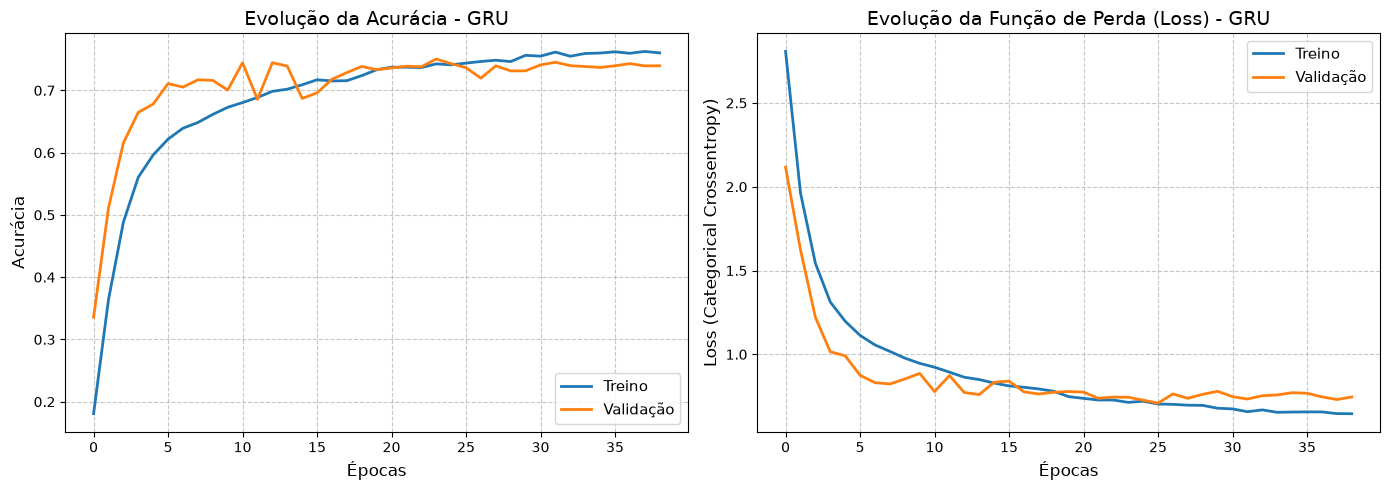

In [3]:
import matplotlib.pyplot as plt

historico = history.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(historico['accuracy'], label='Treino', linewidth=2)
ax1.plot(historico['val_accuracy'], label='Validação', linewidth=2)
ax1.set_title('Evolução da Acurácia - GRU', fontsize=14)
ax1.set_xlabel('Épocas', fontsize=12)
ax1.set_ylabel('Acurácia', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(historico['loss'], label='Treino', linewidth=2)
ax2.plot(historico['val_loss'], label='Validação', linewidth=2)
ax2.set_title('Evolução da Função de Perda (Loss) - GRU', fontsize=14)
ax2.set_xlabel('Épocas', fontsize=12)
ax2.set_ylabel('Loss (Categorical Crossentropy)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('curvas_aprendizado_gru.png', dpi=300) 
plt.show()

Gerando predições para o conjunto de teste...
295/295 [==============================] - 2s 2ms/step


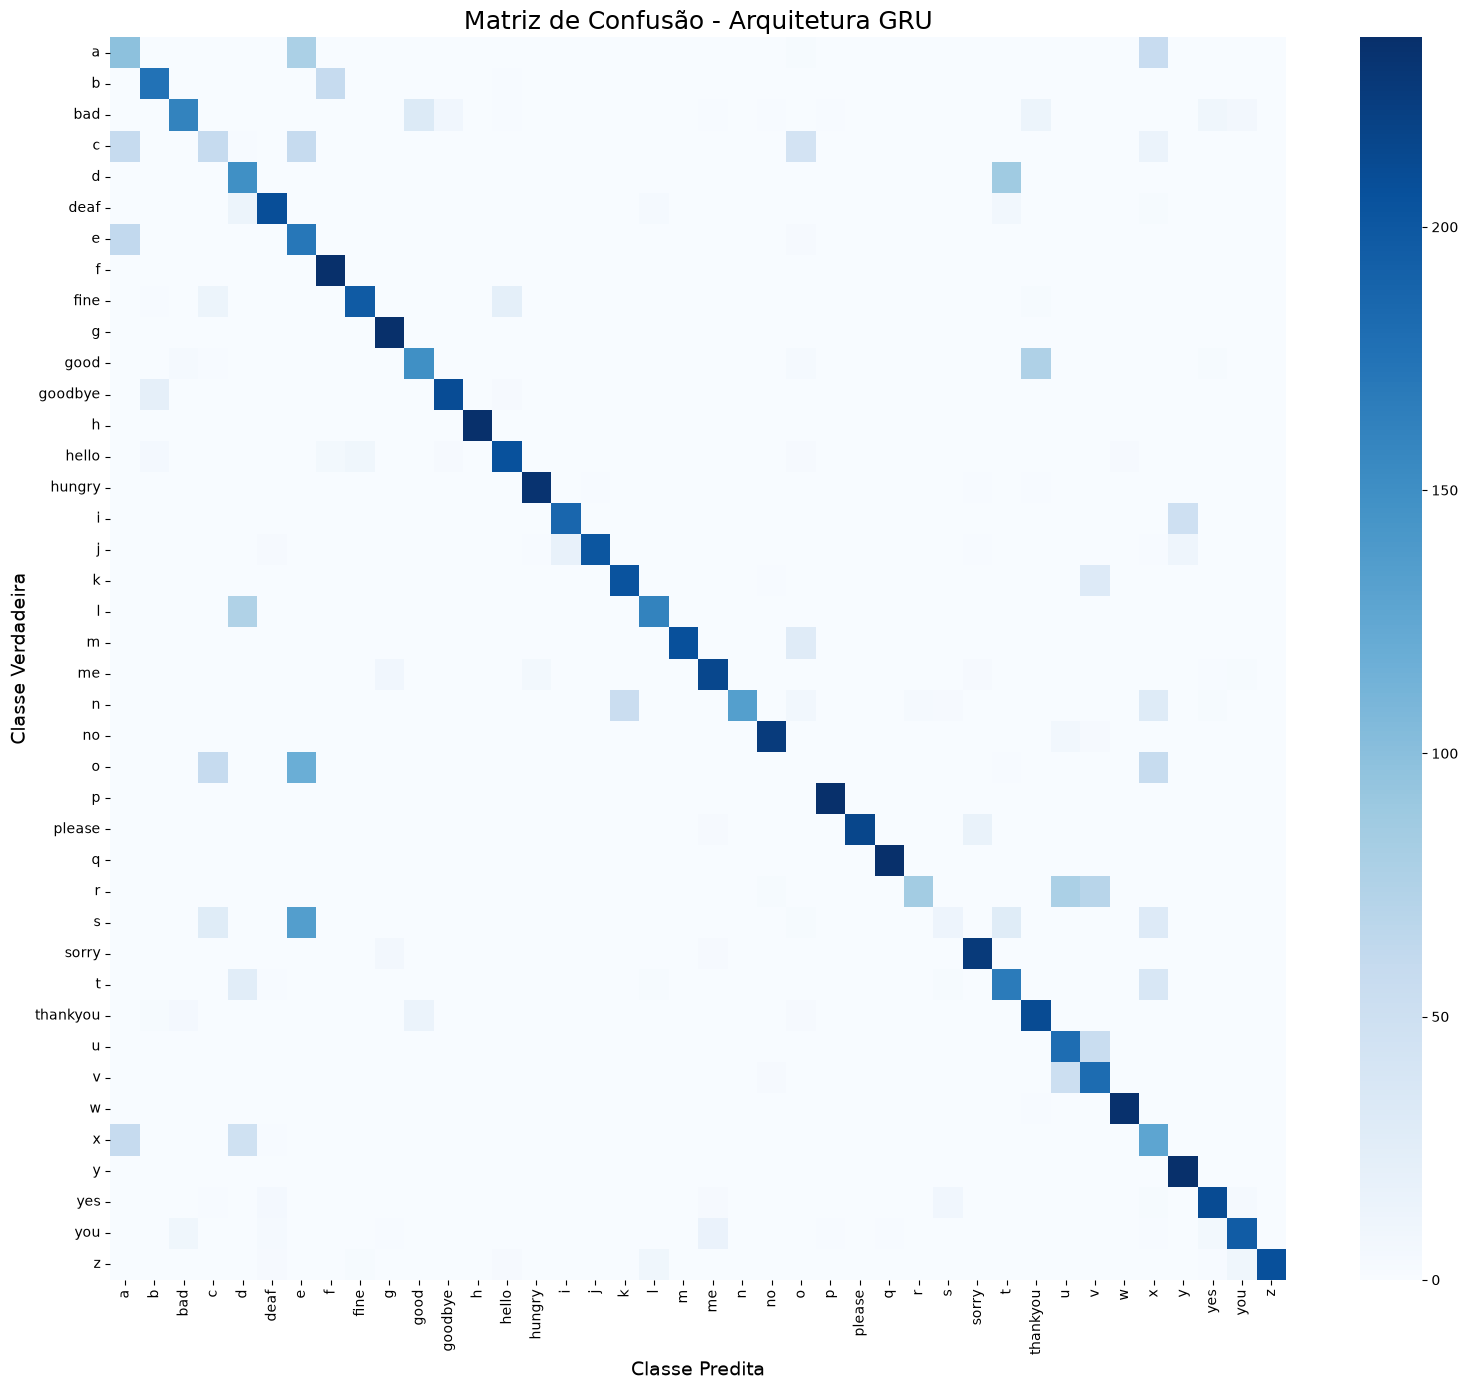

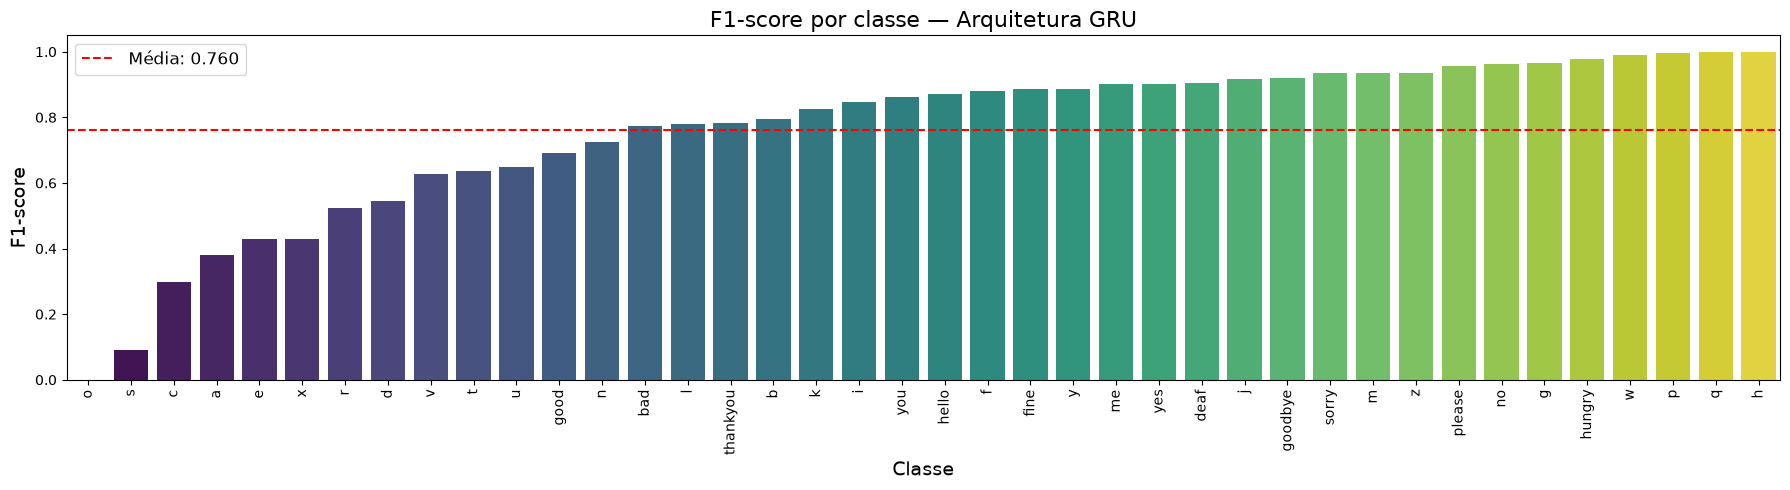


Análise de Erros para o modelo GRU:

--- Top 5 Maiores Confusões ---
Gesto Real: 's              ' confundido com 'e              ' (57.2% das amostras reais)
Gesto Real: 'o              ' confundido com 'e              ' (50.0% das amostras reais)
Gesto Real: 'd              ' confundido com 't              ' (36.9% das amostras reais)
Gesto Real: 'r              ' confundido com 'u              ' (33.5% das amostras reais)
Gesto Real: 'a              ' confundido com 'e              ' (33.5% das amostras reais)


In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report


label_names = [lbl for lbl, idx in sorted(label_map.items(), key=lambda x: x[1])]


print("Gerando predições para o conjunto de teste...")
y_pred_probs = modelo_inferencia.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)


cm_gru_counts = confusion_matrix(y_test, y_pred) 

cm_gru_norm = confusion_matrix(y_test, y_pred, normalize='true') 

report_gru = classification_report(y_test, y_pred, target_names=label_names, output_dict=True)



def analisar_maiores_erros(cm, labels, top_n=5):
    """Identifica os pares de gestos mais confundidos pelo modelo em %."""
    cm_errors = cm.copy()
    np.fill_diagonal(cm_errors, 0) # Zera a diagonal (acertos) para ver só os erros
    
    # Obter os índices das maiores taxas de confusão
    indices = np.argsort(cm_errors, axis=None)[::-1]
    
    print(f"\n--- Top {top_n} Maiores Confusões ---")
    vistos = set()
    count = 0
    for idx in indices:
        if count >= top_n:
            break
        i, j = np.unravel_index(idx, cm_errors.shape)
        if cm_errors[i, j] > 0 and (i, j) not in vistos:
            print(f"Gesto Real: '{labels[i]:<15}' confundido com '{labels[j]:<15}' ({cm_errors[i, j]:.1%} das amostras reais)")
            vistos.add((i, j))
            count += 1

def plot_f1_gru(report, labels):
    """Extrai os valores do report e plota o F1-score ordenado do modelo GRU."""
    f1_values = np.array([report[cls]["f1-score"] for cls in labels])
    
    order = np.argsort(f1_values)
    f1_sorted = f1_values[order]
    labels_sorted = [labels[i] for i in order]

    plt.figure(figsize=(18, 5))
    x_pos = np.arange(len(f1_sorted))
    sns.barplot(x=x_pos, y=f1_sorted, hue=x_pos, palette="viridis", legend=False)
    
    plt.axhline(np.mean(f1_sorted), ls="--", color="red", label=f"Média: {np.mean(f1_sorted):.3f}")
    
    plt.title("F1-score por classe — Arquitetura GRU", fontsize=16)
    plt.ylabel("F1-score", fontsize=14)
    plt.xlabel("Classe", fontsize=14)
    plt.ylim(0, 1.05)
    plt.legend(fontsize=12)

    plt.xticks(x_pos, labels_sorted, rotation=90)
    plt.tight_layout()
    plt.savefig('f1_score_gru.png', dpi=300)
    plt.show()


plt.figure(figsize=(16, 14))
sns.heatmap(cm_gru_counts, annot=False, cmap='Blues', 
            xticklabels=label_names, yticklabels=label_names)
plt.title('Matriz de Confusão - Arquitetura GRU', fontsize=18)
plt.ylabel('Classe Verdadeira', fontsize=14)
plt.xlabel('Classe Predita', fontsize=14)
plt.xticks(rotation=90) 
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('matriz_confusao_gru.png', dpi=300) 
plt.show()


plot_f1_gru(report_gru, label_names)


print("\nAnálise de Erros para o modelo GRU:")
analisar_maiores_erros(cm_gru_norm, label_names, top_n=5)

In [5]:
import numpy as np
import tensorflow as tf
import subprocess
import os
import sys
import tempfile

N_CLASSES = 40


def build_calibration_dataset(X_train, y_train, n_classes,
                               samples_per_class=10, random_seed=42):
    np.random.seed(random_seed)
    indices_selecionados = []
    classes_sem_dados    = []
    classes_com_poucos   = []

    print(f"\n{'─' * 60}")
    print(f"  Construindo dataset de calibração estratificado")
    print(f"  Classes alvo: {n_classes}  |  Amostras por classe: {samples_per_class}")
    print(f"{'─' * 60}")

    for cls in range(n_classes):
        indices_da_classe = np.where(y_train == cls)[0]
        n_disponiveis     = len(indices_da_classe)
        if n_disponiveis == 0:
            classes_sem_dados.append(cls)
            continue
        if n_disponiveis < samples_per_class:
            classes_com_poucos.append((cls, n_disponiveis))
        n_selecionar = min(samples_per_class, n_disponiveis)
        escolhidos   = np.random.choice(indices_da_classe, n_selecionar, replace=False)
        indices_selecionados.extend(escolhidos.tolist())

    np.random.shuffle(indices_selecionados)
    X_cal = X_train[indices_selecionados].astype(np.float32)

    n_classes_ok = n_classes - len(classes_sem_dados)
    print(f"\n  Total de amostras de calibração : {len(X_cal)}")
    print(f"  Classes com cobertura completa  : {n_classes_ok}/{n_classes}")

    if classes_sem_dados:
        print(f"\n  [AVISO] Classes SEM amostras em X_train: {classes_sem_dados}")
    if classes_com_poucos:
        print(f"\n  [AVISO] Classes com menos de {samples_per_class} amostras:")
        for cls, n in classes_com_poucos:
            print(f"          Classe {cls}: apenas {n} amostras disponíveis.")

    return X_cal


_CONVERTER_SCRIPT = """
import sys, numpy as np, tensorflow as tf

model_path  = sys.argv[1]
cal_path    = sys.argv[2]
output_path = sys.argv[3]

model    = tf.keras.models.load_model(model_path)
X_cal    = np.load(cal_path).astype(np.float32)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

def gen():
    for s in X_cal:
        yield [s[np.newaxis].astype(np.float32)]

converter.representative_dataset = gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type     = tf.int8
converter.inference_output_type    = tf.int8

tflite_model = converter.convert()
with open(output_path, "wb") as f:
    f.write(tflite_model)

print(f"OK:{len(tflite_model)}")
"""

def converter_int8(modelo_inferencia, X_calibration,
                   output_path="modelo_gru_quantizado.tflite"):
    print(f"\n{'=' * 60}")
    print(f"  Quantização INT8 — {len(X_calibration)} amostras de calibração")
    print(f"  (rodando em subprocesso isolado para evitar OOM)")
    print(f"{'=' * 60}")

    with tempfile.TemporaryDirectory() as tmp:
        model_path  = os.path.join(tmp, "model.keras")
        cal_path    = os.path.join(tmp, "cal.npy")
        script_path = os.path.join(tmp, "convert.py")

        modelo_inferencia.save(model_path)
        np.save(cal_path, X_calibration)

        with open(script_path, "w") as f:
            f.write(_CONVERTER_SCRIPT)

        print("  Convertendo (pode levar 30–90s)...")
        result = subprocess.run(
            [sys.executable, script_path, model_path, cal_path, output_path],
            capture_output=True, text=True
        )

        if result.returncode != 0:
            print("  [STDERR do subprocesso]:")
            print(result.stderr[-2000:])
            raise RuntimeError("converter_int8 falhou no subprocesso.")

    with open(output_path, "rb") as f:
        tflite_model = f.read()

    tamanho_kb = len(tflite_model) / 1024
    print(f"\n  [OK] Modelo salvo: '{output_path}'")
    print(f"       Tamanho: {tamanho_kb:.1f} KB")

    if tamanho_kb > 512:
        print(f"\n  [AVISO] Modelo > 512 KB! Considere GRU(32) ou WINDOW_SIZE=30.")

    return tflite_model


def verificar_regressao_acuracia(modelo_float, tflite_model_bytes,
                                  X_test, y_test,
                                  n_amostras=300, random_seed=42):
    print(f"\n{'=' * 60}")
    print(f"  Verificação de Regressão de Acurácia (n={n_amostras})")
    print(f"{'=' * 60}")

    np.random.seed(random_seed)
    indices = np.random.choice(len(X_test), min(n_amostras, len(X_test)), replace=False)

    interpreter = tf.lite.Interpreter(model_content=tflite_model_bytes)
    interpreter.allocate_tensors()
    input_det  = interpreter.get_input_details()[0]
    output_det = interpreter.get_output_details()[0]

    in_scale = input_det["quantization_parameters"]["scales"][0]
    in_zp    = input_det["quantization_parameters"]["zero_points"][0]
    out_scale = output_det["quantization_parameters"]["scales"][0]
    out_zp    = output_det["quantization_parameters"]["zero_points"][0]

    print(f"\n  Parâmetros de quantização do INPUT:")
    print(f"    scale = {in_scale:.6f}  |  zero_point = {in_zp}")
    print(f"  Parâmetros de quantização do OUTPUT:")
    print(f"    scale = {out_scale:.6f}  |  zero_point = {out_zp}")

    acertos_float, acertos_int8 = 0, 0
    discordancias = []

    for idx in indices:
        amostra_f32  = X_test[idx:idx+1].astype(np.float32)
        probs_float  = modelo_float(amostra_f32, training=False).numpy()
        pred_float   = int(np.argmax(probs_float))
        if pred_float == y_test[idx]:
            acertos_float += 1

        amostra_int8 = np.clip(
            np.round(amostra_f32 / in_scale) + in_zp,
            -128, 127
        ).astype(np.int8)

        interpreter.set_tensor(input_det["index"], amostra_int8)
        interpreter.invoke()
        output_int8 = interpreter.get_tensor(output_det["index"])
        pred_int8   = int(np.argmax(output_int8))

        if pred_int8 == y_test[idx]:
            acertos_int8 += 1
        if pred_float != pred_int8:
            discordancias.append((idx, pred_float, pred_int8))

    acc_float = 100.0 * acertos_float / len(indices)
    acc_int8  = 100.0 * acertos_int8  / len(indices)
    regressao = acc_float - acc_int8

    print(f"\n  {'Métrica':<30} {'Float32':>10}  {'INT8':>10}")
    print(f"  {'─' * 52}")
    print(f"  {'Acurácia':<30} {acc_float:>9.2f}%  {acc_int8:>9.2f}%")
    print(f"  {'Regressão':<30} {regressao:>10.2f}%")
    print(f"  {'Discordâncias (pred diferentes)':<30} {len(discordancias):>10}")

    print("\n  Diagnóstico:")
    if regressao <= 1.0:
        print("  [✓ ÓTIMO]  Regressão < 1%. Quantização perfeita para produção.")
    elif regressao <= 3.0:
        print("  [✓ OK]     Regressão 1–3%. Aceitável para o ESP32-S3.")
    elif regressao <= 7.0:
        print("  [! AVISO]  Regressão 3–7%. Aumente samples_per_class para 20.")
    else:
        print("  [✗ CRÍTICO] Regressão > 7%! Verifique a pipeline de normalização.")

    return acc_float, acc_int8, regressao


def gerar_header_c(tflite_path="modelo_gru_quantizado.tflite",
                   header_path="modelo_gru_quantizado.h"):
    with open(tflite_path, "rb") as f:
        data = f.read()

    hex_lines = []
    for i in range(0, len(data), 12):
        chunk = data[i:i+12]
        hex_lines.append("  " + ", ".join(f"0x{b:02x}" for b in chunk))

    var_name          = os.path.basename(tflite_path).replace(".", "_").replace("-", "_")
    linhas_formatadas = ",\n".join(hex_lines)

    header = f"""\
// ==========================================================================
// {header_path}  —  Modelo GRU ASL quantizado INT8
// Tamanho: {len(data):,} bytes ({len(data)/1024:.1f} KB)
// NÃO EDITAR MANUALMENTE.
// ==========================================================================
#pragma once
#include <stdint.h>

#ifdef ASL_MODEL_IMPLEMENTATION
const uint8_t {var_name}[] __attribute__((aligned(4))) = {{
{linhas_formatadas}
}};
const unsigned int {var_name}_len = {len(data)}U;
#else
extern const uint8_t {var_name}[];
extern const unsigned int {var_name}_len;
#endif
"""
    with open(header_path, "w") as f:
        f.write(header)

    print(f"\n  [OK] Header C gerado: '{header_path}'")
    print(f"       {len(data):,} bytes → {len(data)//1024} KB na flash do ESP32-S3")


def run_3(modelo_inferencia, X_train, y_train, X_test, y_test,
                 n_classes=N_CLASSES, samples_per_class=10):

    X_cal = build_calibration_dataset(
        X_train, y_train,
        n_classes=n_classes,
        samples_per_class=samples_per_class
    )

    tflite_bytes = converter_int8(
        modelo_inferencia, X_cal,
        output_path="modelo_gru_quantizado.tflite"
    )

    acc_f32, acc_int8, regressao = verificar_regressao_acuracia(
        modelo_inferencia, tflite_bytes,
        X_test, y_test,
        n_amostras=300
    )

    if regressao > 3.0 and samples_per_class < 30:
        novo_spc = min(samples_per_class * 2, 30)
        print(f"\n  [AUTO-CORREÇÃO] Regressão > 3%. Repetindo com {novo_spc} amostras/classe...")
        return run_3(
            modelo_inferencia, X_train, y_train, X_test, y_test,
            n_classes=n_classes, samples_per_class=novo_spc
        )

    gerar_header_c("modelo_gru_quantizado.tflite", "modelo_gru_quantizado.h")

    print("\n" + "=" * 60)
    print("Arquivos gerados:")
    print("  → modelo_gru_quantizado.tflite")
    print("  → modelo_gru_quantizado.h")
    print("=" * 60)

    return tflite_bytes, acc_f32, acc_int8, regressao


tflite_bytes, acc_f32, acc_int8, regressao = run_3(
    modelo_inferencia,
    X_train, y_train,
    X_test, y_test,
    n_classes=N_CLASSES,
    samples_per_class=10
)


────────────────────────────────────────────────────────────
  Construindo dataset de calibração estratificado
  Classes alvo: 40  |  Amostras por classe: 10
────────────────────────────────────────────────────────────

  Total de amostras de calibração : 400
  Classes com cobertura completa  : 40/40

  Quantização INT8 — 400 amostras de calibração
  (rodando em subprocesso isolado para evitar OOM)
  Convertendo (pode levar 30–90s)...

  [OK] Modelo salvo: 'modelo_gru_quantizado.tflite'
       Tamanho: 309.3 KB

  Verificação de Regressão de Acurácia (n=300)

  Parâmetros de quantização do INPUT:
    scale = 0.152716  |  zero_point = 61
  Parâmetros de quantização do OUTPUT:
    scale = 0.003906  |  zero_point = -128


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.



  Métrica                           Float32        INT8
  ────────────────────────────────────────────────────
  Acurácia                           73.67%      67.00%
  Regressão                            6.67%
  Discordâncias (pred diferentes)         43

  Diagnóstico:
  [! AVISO]  Regressão 3–7%. Aumente samples_per_class para 20.

  [AUTO-CORREÇÃO] Regressão > 3%. Repetindo com 20 amostras/classe...

────────────────────────────────────────────────────────────
  Construindo dataset de calibração estratificado
  Classes alvo: 40  |  Amostras por classe: 20
────────────────────────────────────────────────────────────

  Total de amostras de calibração : 800
  Classes com cobertura completa  : 40/40

  Quantização INT8 — 800 amostras de calibração
  (rodando em subprocesso isolado para evitar OOM)
  Convertendo (pode levar 30–90s)...

  [OK] Modelo salvo: 'modelo_gru_quantizado.tflite'
       Tamanho: 306.3 KB

  Verificação de Regressão de Acurácia (n=300)

  Parâmetros de quantiza